# Titanic predicción con Random Forest

Intenta aplicar lo aprendido con las lecciones de ingeniería de propiedades con el conjunto de datos de Titanic disponible en Kaggle. Este dataset es accesible y contiene una mezcla de tipos de datos categóricos y numéricos, lo que lo hace perfecto para ejercitar diversas técnicas de ingeniería de propiedades. La tarea consiste en predecir la supervivencia de los pasajeros del Titanic utilizando machine learning.

Tareas Específicas:

1. Análisis Exploratorio de Datos (EDA): Buscar valores faltantes e identifica las posibles relaciones entre las características y la variable objetivo.

2. Limpieza de Datos: Basándose en el EDA debes tratar los valores faltantes y corregir posibles errores en los datos

3. Construye un modelo base para poder comparar sus resultados con otros después de aplicar ingeniería de propiedades.

4.  Elimina las características irrelevantes y prueba el modelo, si no hay mejora no las quites. 

5. Aplicar técnicas de ingeniería de propiedades para transformar y crear nuevas características. Algunas sugerencias:

Crea una característica de "Tamaño de la familia" sumando las características SibSp (número de hermanos/cónyuges a bordo) y Parch (número de padres/hijos a bordo).
Extrae el título de la característica Name y usarlo para crear una nueva característica que pueda indicar el estatus social o el género, lo que podría influir en la supervivencia.
Crea bandas de edad para transformar la edad en una característica categórica, facilitando la captura de relaciones no lineales con la supervivencia.
Aplica target encoding a la característica Cabin considerando la letra de la cabina como una indicación de la cubierta, lo que podría afectar las posibilidades de supervivencia.
Prueba con random forest.

### Preparación de datos

In [640]:
import pandas as pd
import numpy as np

# Lee los datos
trd = pd.read_csv('./data/train.csv')
tsd = pd.read_csv('./data/test.csv')
gender_submission = pd.read_csv('./data/gender_submission.csv')

# Combina los datos de entrenamiento y prueba en un solo DataFrame
df = pd.concat([trd, tsd], ignore_index=True, sort=False)

# Fusiona gender_submission en df usando PassengerId como clave de unión
df_merged = pd.merge(df, gender_submission, on='PassengerId', how='left')

# Define una función para reemplazar NaN en 'Survived'
def fill_survived(row):
    if pd.isna(row['Survived']):
        passenger_id = row['PassengerId']
        survived_value = gender_submission.loc[gender_submission['PassengerId'] == passenger_id, 'Survived'].values[0]
        return survived_value
    else:
        return row['Survived']

# Aplica la función a la columna 'Survived' de df
df['Survived'] = df.apply(fill_survived, axis=1)

# Verifica los primeros registros para confirmar la sustitución
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [641]:
df.shape

(1309, 12)

In [642]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [643]:
# Variable objetivo convertir a int
df['Survived'] = df['Survived'].astype(int)

In [644]:
# Rows = 1309
if (df.isna().sum() > 0).any():
    print(df.isna().sum()[df.isna().sum() > 0])

Age          263
Fare           1
Cabin       1014
Embarked       2
dtype: int64


In [645]:
# Embarked rellenamos con la moda porque asumimos que es la más probable
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Fare rellenamos con la media porque 
df['Fare'].fillna(df['Fare'].mean(), inplace=True)

# Age rellenamos con la media porque asumimos que es la más probable
#df['Age'].fillna('unknown', inplace=True)

# Cabine rellenamos con 'unknown' para no perder la información
df['Cabin'].fillna('unknown', inplace=True)

C:\Users\vober\AppData\Local\Temp\ipykernel_4604\3590733559.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
C:\Users\vober\AppData\Local\Temp\ipykernel_4604\3590733559.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

In [646]:
# veremos la edad media de hombres y mujeres y se la asignaré a los valores nulos en esta primera toma de contacto
age_by_sex = df.groupby('Sex')['Age'].mean()

# Rellenar los valores nulos en 'Age' con la media por género
df['Age'] = df.apply(lambda row: age_by_sex[row['Sex']] if pd.isnull(row['Age']) else row['Age'], axis=1)

# Verificar si hay valores nulos después de la imputación
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [647]:
if (df.isna().sum() > 0).any():
    print(df.isna().sum()[df.isna().sum() > 0])

### Mutual Information

In [648]:
from sklearn.feature_selection import mutual_info_classif

# ver la influencía del target con las características con el mutual information
df2 = df.copy()
target = df2.pop('Survived')

# Label encoding para las variables categóricas
for colname in df2.select_dtypes("object"):
    df2[colname], _ = df2[colname].factorize() # Se convierte a numérico

discrete_features = df2.dtypes == int

In [649]:
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(df2, target, discrete_features)

mi_scores

Sex            0.271843
Fare           0.113934
Ticket         0.062323
Age            0.062186
Cabin          0.033253
Pclass         0.017385
Embarked       0.014093
SibSp          0.013866
Parch          0.006702
Name           0.004511
PassengerId    0.003748
Name: MI Scores, dtype: float64

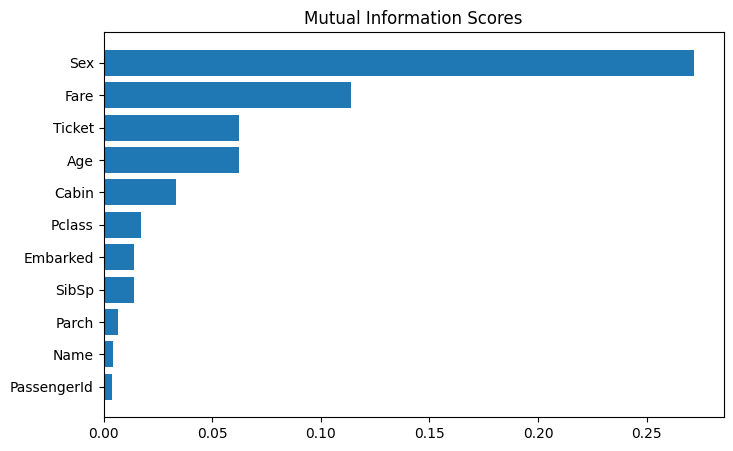

In [650]:
# Dibujar el gráfico de barras
from matplotlib import pyplot as plt

def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

## Modelo base

In [651]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(random_state = 42)
scores = cross_val_score(model, df2, target).mean()
scores

0.8603053435114504

### Ingeniería de propiedades

In [652]:
df2.drop(['Name'], axis=1, inplace=True)

scores = cross_val_score(model, df2, target).mean()
scores

0.8633529291333977

In [653]:
df2.drop(['Embarked'], axis=1, inplace=True)

scores = cross_val_score(model, df2, target).mean()
scores

0.8641162879120236

In [654]:
# df2.drop(['PassengerId'], axis=1, inplace=True)

# scores = cross_val_score(model, df2, target).mean()
# scores # Output: 0.8564534526629816 . Empeora

## Creación característica "Tamaño de familia" sumando SibSp y Parch

In [655]:
# Se añade 1 porque incluye al pasajero mismo
df2["FamilySize"] = df2.SibSp + df.Parch + 1
scores = cross_val_score(model, df2, target).mean()
scores

0.8618232868298676

### Extrae el título de la característica Name y usarlo para crear una nueva característica que pueda indicar el estatus social o el género, lo que podría influir en la supervivencia.

title_mapping = {
    "Mr": "Mr",
    "Miss": "Miss",
    "Mrs": "Mrs",
    "Master": "Master",
    "Dr": "Dr",
    "Rev": "Rev",
    "Major": "Officer",
    "Col": "Officer",
    "Capt": "Officer",
    "Jonkheer": "Noble",
    "Don": "Noble",
    "Sir": "Noble",
    "Lady": "Noble",
    "Countess": "Noble",
    "Dona": "Noble",
    "Mme": "Mrs",
    "Ms": "Miss",
    "Mlle": "Miss"
}

In [656]:
# Extraer el título de la característica 'Name'
df2['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Mapear los títulos a categorías más generales que indiquen estatus social o género
title_mapping = {
    "Mr": "1",
    "Miss": "2",
    "Mrs": "3",
    "Master": "4",
    "Dr": "5",
    "Rev": "6",
    "Major": "7",
    "Col": "7",
    "Capt": "7",
    "Jonkheer": "8",
    "Don": "8",
    "Sir": "8",
    "Lady": "8",
    "Countess": "8",
    "Dona": "8",
    "Mme": "3",
    "Ms": "2",
    "Mlle": "2"
}

# Aplicar el mapeo al título
df2['Title'] = df2['Title'].map(title_mapping)

# Mostrar el DataFrame con la nueva característica 'Title'
df2


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,Title
0,1,3,0,22.000000,1,0,0,7.2500,0,2,1
1,2,1,1,38.000000,1,0,1,71.2833,1,2,3
2,3,3,1,26.000000,0,0,2,7.9250,0,1,2
3,4,1,1,35.000000,1,0,3,53.1000,2,2,3
4,5,3,0,35.000000,0,0,4,8.0500,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,0,30.585228,0,0,926,8.0500,0,1,1
1305,1306,1,1,39.000000,0,0,273,108.9000,186,1,8
1306,1307,3,0,38.500000,0,0,927,7.2500,0,1,1
1307,1308,3,0,30.585228,0,0,928,8.0500,0,1,1


In [657]:
scores = cross_val_score(model, df2, target).mean()
scores

0.8671609487876927

### Crea bandas de edad para transformar la edad en una característica categórica, facilitando la captura de relaciones no lineales con la supervivencia.

In [658]:
# Definir las bandas de edad y etiquetas correspondientes
age_bins = [0, 20, 30, 50, 80]  # Definir los límites de las bandas de edad
age_labels = ['Child', 'Young Adult', 'Adult', 'Senior']  # Etiquetas para cada banda de edad

# Crear una nueva columna 'AgeBand' que represente la banda de edad
# pd.cut: Devuelve una nueva serie cuyos elementos son los valores de 'Age' asignados a las bandas correspondientes 
df2['AgeBand'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Aplicar One-Hot Encoding a la columna 'AgeBand'
age_band_one_hot = pd.get_dummies(df2['AgeBand'], prefix='AgeBand')

# Concatenar el DataFrame original 'df' con las nuevas columnas generadas por One-Hot Encoding
df2 = pd.concat([df2, age_band_one_hot], axis=1)

# Eliminar la columna original 'Age' y 'AgeBand' ya que ahora están codificadas
df2.drop(['Age', 'AgeBand'], axis=1, inplace=True)

# Mostrar el DataFrame con las nuevas columnas One-Hot Encoded para las bandas de edad
df2

,PassengerId,Pclass,Sex,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,Title,AgeBand_Child,AgeBand_Young Adult,AgeBand_Adult,AgeBand_Senior
0,1,3,0,1,0,0,7.2500,0,2,1,False,True,False,False
1,2,1,1,1,0,1,71.2833,1,2,3,False,False,True,False
2,3,3,1,0,0,2,7.9250,0,1,2,False,True,False,False
3,4,1,1,1,0,3,53.1000,2,2,3,False,False,True,False
4,5,3,0,0,0,4,8.0500,0,1,1,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,0,0,0,926,8.0500,0,1,1,False,False,True,False
1305,1306,1,1,0,0,273,108.9000,186,1,8,False,False,True,False
1306,1307,3,0,0,0,927,7.2500,0,1,1,False,False,True,False
1307,1308,3,0,0,0,928,8.0500,0,1,1,False,False,True,False


In [659]:
scores = cross_val_score(model, df2, target).mean()
scores

0.8671638735339708

### Aplica target encoding a la característica Cabin considerando la letra de la cabina como una indicación de la cubierta, lo que podría afectar las posibilidades de supervivencia.

In [660]:
# Extraer la letra de la cabina como la categoría de cubierta (deck)
df2['Deck'] = df['Cabin'].str.slice(0, 1)

# Añadir 'Survived' a df2 para calcular las tasas de supervivencia por cubierta
df2['Survived'] = target

# Calcular la tasa de supervivencia promedio por cada categoría de cubierta (deck)
deck_survival_rates = df2.groupby('Deck')['Survived'].mean()

# Aplicar target encoding a la columna 'Deck' basado en las tasas de supervivencia promedio
df2['Deck_Encoded'] = df2['Deck'].map(deck_survival_rates)

# Elimina las columnas 'Deck' y 'Survived' ya que no se necesitan
df2.drop(['Deck', 'Survived'], axis=1, inplace=True)

# Mostrar el DataFrame con el target encoding aplicado a la característica 'Cabin'
df2

,PassengerId,Pclass,Sex,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,Title,AgeBand_Child,AgeBand_Young Adult,AgeBand_Adult,AgeBand_Senior,Deck_Encoded
0,1,3,0,1,0,0,7.2500,0,2,1,False,True,False,False,0.309665
1,2,1,1,1,0,1,71.2833,1,2,3,False,False,True,False,0.574468
2,3,3,1,0,0,2,7.9250,0,1,2,False,True,False,False,0.309665
3,4,1,1,1,0,3,53.1000,2,2,3,False,False,True,False,0.574468
4,5,3,0,0,0,4,8.0500,0,1,1,False,False,True,False,0.309665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,0,0,0,926,8.0500,0,1,1,False,False,True,False,0.309665
1305,1306,1,1,0,0,273,108.9000,186,1,8,False,False,True,False,0.574468
1306,1307,3,0,0,0,927,7.2500,0,1,1,False,False,True,False,0.309665
1307,1308,3,0,0,0,928,8.0500,0,1,1,False,False,True,False,0.309665


In [661]:
scores = cross_val_score(model, df2, target).mean()
scores

0.8625778713696587

### Escalamiento de los datos

In [662]:
from sklearn.preprocessing import StandardScaler

# Supongamos que tienes un DataFrame 'df2' con las características incluyendo 'Deck_Encoded'

# Crear un StandardScaler
scaler = StandardScaler()

# Seleccionar todas las características numéricas para escalar
numeric_features = df2.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Escalar las características seleccionadas
df2[numeric_features] = scaler.fit_transform(df2[numeric_features])

# Mostrar el DataFrame con las características escaladas
df2


,PassengerId,Pclass,Sex,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,Title,AgeBand_Child,AgeBand_Young Adult,AgeBand_Adult,AgeBand_Senior,Deck_Encoded
0,-1.730728,0.841916,-0.743497,0.481288,-0.445000,-1.514068,-0.503595,-0.435622,0.073352,1,False,True,False,False,-0.517635
1,-1.728082,-1.546098,1.344995,0.481288,-0.445000,-1.510333,0.734503,-0.412173,0.073352,3,False,False,True,False,1.506378
2,-1.725435,0.841916,1.344995,-0.479087,-0.445000,-1.506599,-0.490544,-0.435622,-0.558346,2,False,True,False,False,-0.517635
3,-1.722789,-1.546098,1.344995,0.481288,-0.445000,-1.502864,0.382925,-0.388725,0.073352,3,False,False,True,False,1.506378
4,-1.720143,0.841916,-0.743497,-0.479087,-0.445000,-1.499129,-0.488127,-0.435622,-0.558346,1,False,False,True,False,-0.517635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1.720143,0.841916,-0.743497,-0.479087,-0.445000,1.944191,-0.488127,-0.435622,-0.558346,1,False,False,True,False,-0.517635
1305,1.722789,-1.546098,1.344995,-0.479087,-0.445000,-0.494516,1.461829,3.925868,-0.558346,8,False,False,True,False,1.506378
1306,1.725435,0.841916,-0.743497,-0.479087,-0.445000,1.947926,-0.503595,-0.435622,-0.558346,1,False,False,True,False,-0.517635
1307,1.728082,0.841916,-0.743497,-0.479087,-0.445000,1.951661,-0.488127,-0.435622,-0.558346,1,False,False,True,False,-0.517635


In [663]:
scores = cross_val_score(model, df2, target).mean()
scores

0.8625778713696587